# Sprint 3b — Visualizações Finais

**Projeto:** Identificação de Regimes Operacionais em Moagem Industrial  
**Autor:** Tarcizo Junior  
**Objetivo:** Gerar visualizações limpas e consolidadas para o relatório e o pitch.

**Etapas:**
1. Panorama geral do pipeline (do dado bruto ao classificador)
2. Resumo visual dos 3 regimes operacionais
3. Performance do classificador — gráfico limpo
4. SHAP — top features (versão simplificada para pitch)
5. Timeline dos regimes (amostra representativa)
6. Comparação regimes vs dureza (resumo visual)

In [1]:
# ==============================================================================
# Setup: caminhos e imports do projeto
# ==============================================================================
import sys, warnings, re
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado")

DATA_RAW     = PROJECT_ROOT / "data" / "raw"
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
DATA_LABEL   = PROJECT_ROOT / "data" / "labeled"
FIGURES_DIR  = PROJECT_ROOT / "figures" / "03_sprint3"
MODELS_DIR   = PROJECT_ROOT / "models"
REPORTS_DIR  = PROJECT_ROOT / "reports"

SCRIPTS_DIR = PROJECT_ROOT / "utils"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

for d in [DATA_PROC, DATA_LABEL, FIGURES_DIR, MODELS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

from db_utils import carregar_dados, salvar_dataframe, salvar_imagem, criar_tabelas
criar_tabelas()

STAGE = "S3b"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({
    'axes.titlesize': 19,
    'figure.titlesize': 21,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

def nome_curto(col):
    nome = col.replace("_pipoint", "").strip()
    nome = re.sub(r'^\d{4}_', '', nome)
    nome = re.sub(r'\s*_\s*', ' ', nome).strip()
    return nome

REGIME_COLORS = {0: '#1f77b4', 1: '#2ca02c', 2: '#d62728'}
REGIME_NAMES  = {0: 'R0 — Carga Reduzida', 1: 'R1 — Moderado', 2: 'R2 — Alta Carga'}

print(f"Setup concluído. STAGE = {STAGE}")

[db_utils] Schema 'otimizar_moagem_aura' e tabelas criados/verificados com sucesso


Setup concluído. STAGE = S3b


In [2]:
# Carregar dados necessários
df_rotulado = carregar_dados("dados_rotulados")
if "Timestamp" in df_rotulado.columns:
    df_rotulado = df_rotulado.set_index("Timestamp").sort_index()

df_pred = pd.read_parquet(DATA_LABEL / "predicoes_teste.parquet")
df_comp_modelos = pd.read_csv(DATA_LABEL / "comparacao_modelos.csv")
df_temporal = pd.read_csv(DATA_PROC / "s3a_validacao_temporal.csv")
df_temporal['periodo_inicio'] = pd.to_datetime(df_temporal['periodo_inicio'])
df_resultados = pd.read_csv(DATA_PROC / "s3a_resultados_validacao.csv")

print("Dados carregados.")

[db_utils] 632985 linhas carregadas de otimizar_moagem_aura.dados_rotulados
Dados carregados.


---
## 1 — Distribuição dos Regimes Operacionais

**Objetivo:** Visualização clara da proporção de cada regime no período analisado.

[db_utils] Imagem 'distribuicao_regimes' salva para etapa S3b


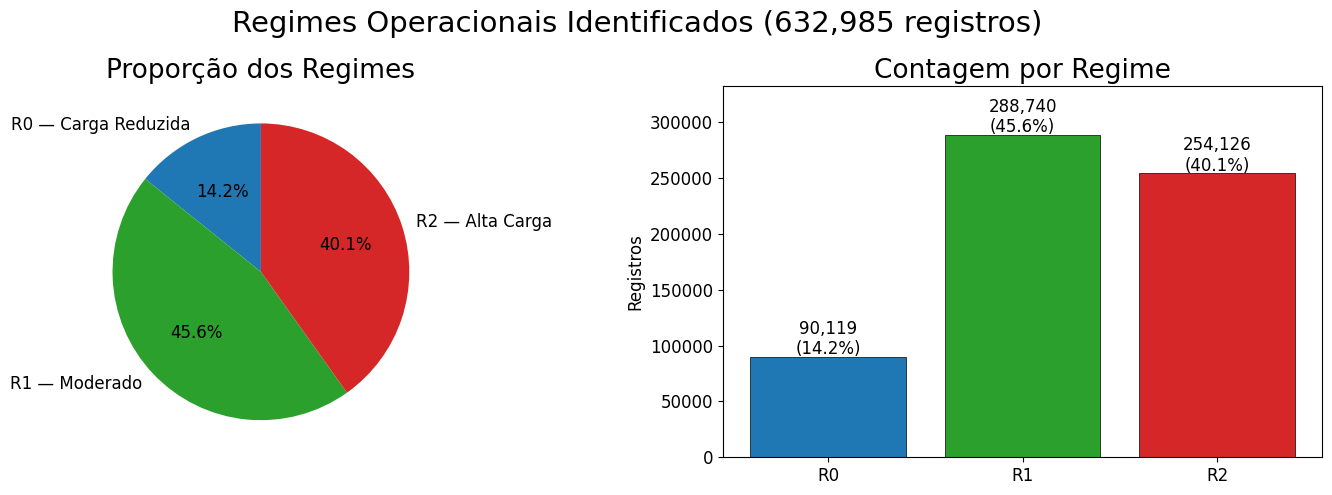

In [3]:
# Distribuição dos regimes (pizza + barras)
regime_counts = df_rotulado['regime'].value_counts().sort_index()
regime_pcts = regime_counts / regime_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pizza
colors = [REGIME_COLORS[i] for i in regime_counts.index]
labels = [REGIME_NAMES[i] for i in regime_counts.index]
wedges, texts, autotexts = axes[0].pie(
    regime_counts.values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(12)
axes[0].set_title('Proporção dos Regimes', fontsize=19)

# Barras com contagem
bars = axes[1].bar(
    [f'R{i}' for i in regime_counts.index],
    regime_counts.values,
    color=colors, edgecolor='black', linewidth=0.5
)
for bar, pct in zip(bars, regime_pcts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{bar.get_height():,.0f}\n({pct:.1f}%)',
                 ha='center', fontsize=12)
axes[1].set_ylabel('Registros', fontsize=12)
axes[1].set_title('Contagem por Regime', fontsize=19)
axes[1].set_ylim(0, regime_counts.max() * 1.15)

fig.suptitle(f'Regimes Operacionais Identificados ({len(df_rotulado):,} registros)', fontsize=21)
plt.tight_layout()

fig.savefig(FIGURES_DIR / "S3b_01_distribuicao_regimes.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "distribuicao_regimes", fig, "S3b_01_distribuicao_regimes.png")
plt.show()

---
## 2 — Comparação de Modelos (Performance)

**Objetivo:** Visualização clara da performance dos 3 modelos testados, destacando o LightGBM como melhor modelo.

[db_utils] Imagem 'comparacao_modelos' salva para etapa S3b


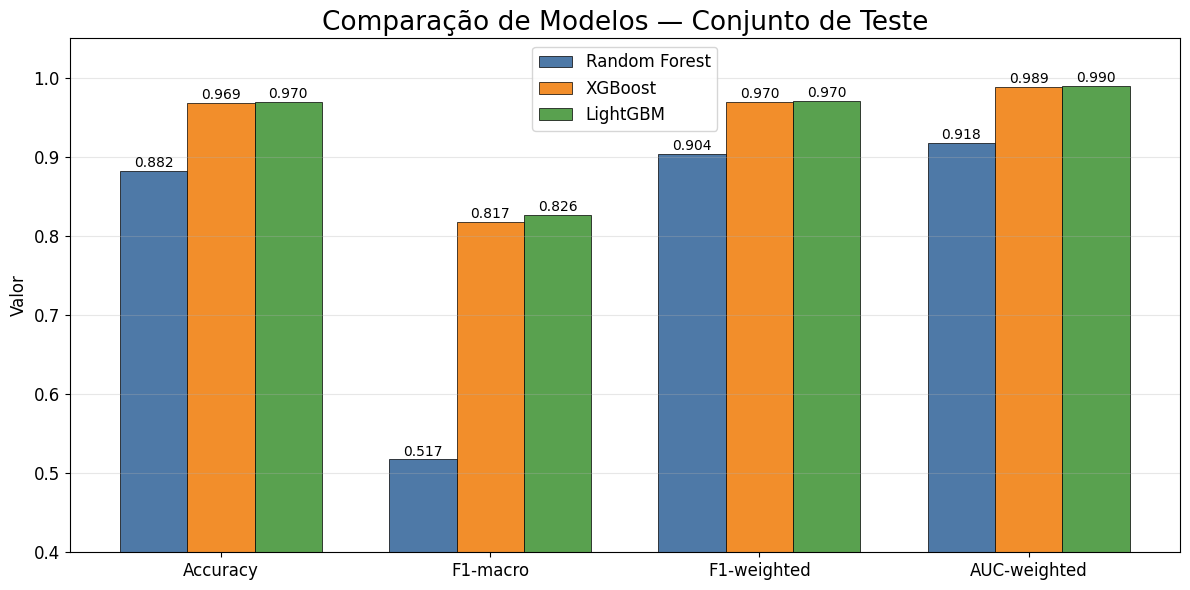

In [4]:
# Comparação de modelos — barras agrupadas
metricas_plot = ['Accuracy', 'F1-macro', 'F1-weighted', 'AUC-weighted']
modelos = df_comp_modelos['Modelo'].tolist()

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metricas_plot))
width = 0.25
cores_modelo = ['#4e79a7', '#f28e2b', '#59a14f']

for i, modelo in enumerate(modelos):
    valores = [df_comp_modelos.loc[df_comp_modelos['Modelo'] == modelo, m].values[0]
               for m in metricas_plot]
    bars = ax.bar(x + i * width, valores, width, label=modelo,
                  color=cores_modelo[i], edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=10)

ax.set_xticks(x + width)
ax.set_xticklabels(metricas_plot, fontsize=12)
ax.set_ylabel('Valor', fontsize=12)
ax.set_ylim(0.4, 1.05)
ax.set_title('Comparação de Modelos — Conjunto de Teste', fontsize=19)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

fig.savefig(FIGURES_DIR / "S3b_02_comparacao_modelos.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "comparacao_modelos", fig, "S3b_02_comparacao_modelos.png")
plt.show()

---
## 3 — Timeline dos Regimes (Amostra)

**Objetivo:** Mostrar como os regimes se alternam ao longo do tempo, dando intuição sobre a dinâmica operacional.

Amostra: 2025-05-12 a 2025-05-26 (17,170 registros)


[db_utils] Imagem 'timeline_regimes' salva para etapa S3b


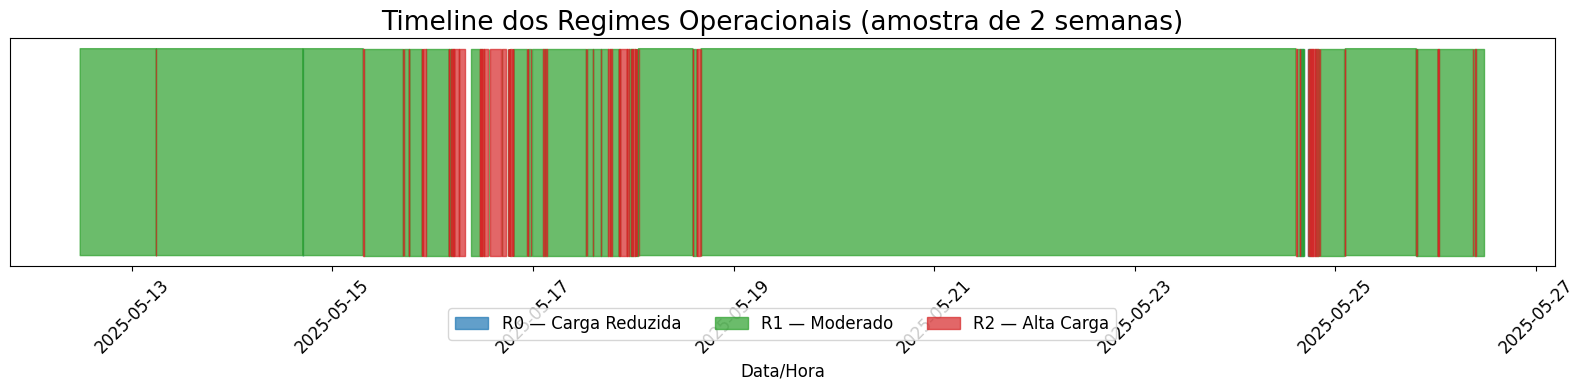

In [5]:
# Timeline de regimes — amostra de 2 semanas
# Escolher um período representativo no meio do dataset
meio = df_rotulado.index[len(df_rotulado)//2]
inicio = meio - pd.Timedelta(days=7)
fim = meio + pd.Timedelta(days=7)

df_amostra = df_rotulado.loc[inicio:fim].copy()
print(f"Amostra: {inicio.date()} a {fim.date()} ({len(df_amostra):,} registros)")

fig, ax = plt.subplots(figsize=(16, 4))

for regime_id in sorted(df_amostra['regime'].unique()):
    mask = df_amostra['regime'] == regime_id
    ax.fill_between(df_amostra.index, 0, 1, where=mask,
                    color=REGIME_COLORS[int(regime_id)], alpha=0.7,
                    label=REGIME_NAMES[int(regime_id)])

ax.set_yticks([])
ax.set_xlabel('Data/Hora', fontsize=12)
ax.set_title('Timeline dos Regimes Operacionais (amostra de 2 semanas)', fontsize=19)
ax.legend(loc='upper center', ncol=3, fontsize=12, bbox_to_anchor=(0.5, -0.15))
plt.xticks(rotation=45)
plt.tight_layout()

fig.savefig(FIGURES_DIR / "S3b_03_timeline_regimes.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "timeline_regimes", fig, "S3b_03_timeline_regimes.png")
plt.show()

---
## 4 — Radar Chart — Perfil dos Regimes

**Objetivo:** Visualização compacta do perfil operacional de cada regime, normalizando as variáveis-chave para escala comparável.

[db_utils] Imagem 'radar_regimes' salva para etapa S3b


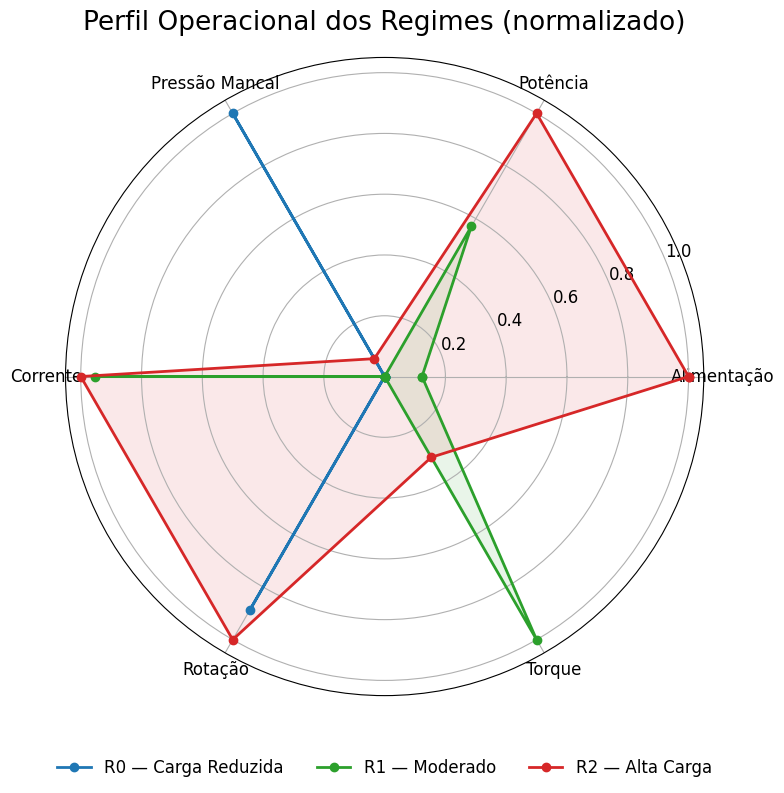

In [6]:
# Radar chart dos regimes
VARS_RADAR = {
    '1025_RETOMADA _ TR02 _ BALANÇA_pipoint': 'Alimentação',
    '1030_MOAGEM _ MO01 _ POTÊNCIA_pipoint': 'Potência',
    '1030_MOAGEM _ MO01MANCALENTRADA _ PRESSÃO_pipoint': 'Pressão Mancal',
    '1030_MOAGEM _ MO01 _ CORRENTE_pipoint': 'Corrente',
    '1030_MOAGEM _ MO01 _ ROTAÇÃO_pipoint': 'Rotação',
    '1030_MOAGEM _ MO01 _ TORQUE_pipoint': 'Torque',
}

# Calcular médias normalizadas por regime (min-max)
medias = {}
for regime_id in sorted(df_rotulado['regime'].unique()):
    mask = df_rotulado['regime'] == regime_id
    medias[int(regime_id)] = {nome: df_rotulado.loc[mask, col].mean()
                              for col, nome in VARS_RADAR.items()
                              if col in df_rotulado.columns}

df_medias = pd.DataFrame(medias).T

# Normalizar 0-1 por variável
df_norm = (df_medias - df_medias.min()) / (df_medias.max() - df_medias.min())

# Radar
categorias = list(df_norm.columns)
N = len(categorias)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # fechar o polígono

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for regime_id in df_norm.index:
    values = df_norm.loc[regime_id].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2,
            color=REGIME_COLORS[regime_id], label=REGIME_NAMES[regime_id])
    ax.fill(angles, values, alpha=0.1, color=REGIME_COLORS[regime_id])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categorias, fontsize=12)
ax.set_title('Perfil Operacional dos Regimes (normalizado)', fontsize=19, pad=20)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), fontsize=12, ncol=3,
          frameon=False)
plt.tight_layout()

fig.savefig(FIGURES_DIR / "S3b_04_radar_regimes.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "radar_regimes", fig, "S3b_04_radar_regimes.png")
plt.show()

---
## 5 — Validação Temporal (versão limpa para pitch)

**Objetivo:** Versão simplificada do gráfico de estabilidade temporal, focada na mensagem principal.

[db_utils] Imagem 'estabilidade_temporal_pitch' salva para etapa S3b


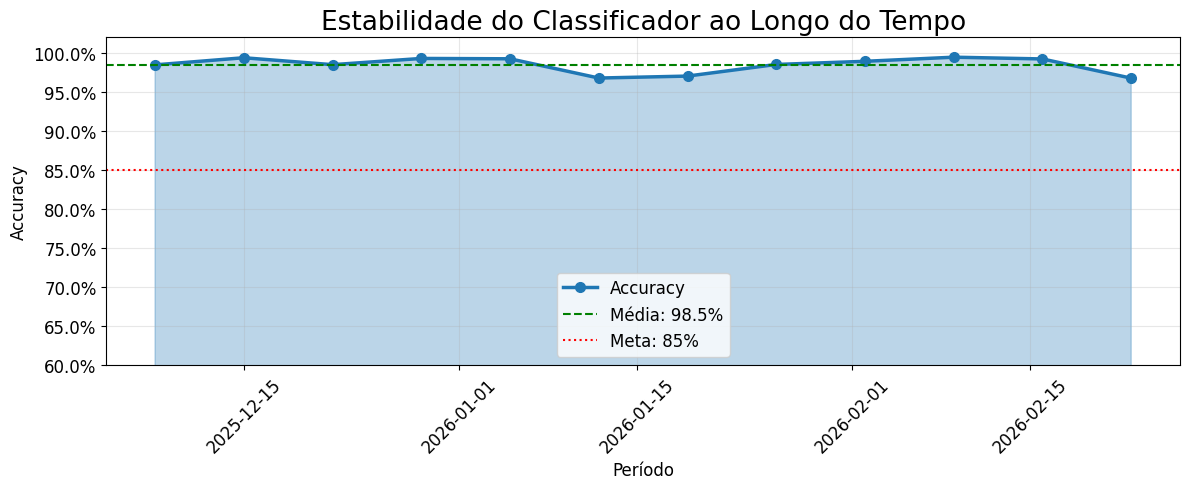

In [7]:
# Validação temporal — versão pitch
fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(df_temporal['periodo_inicio'], df_temporal['accuracy'],
                alpha=0.3, color='#1f77b4')
ax.plot(df_temporal['periodo_inicio'], df_temporal['accuracy'],
        'o-', color='#1f77b4', linewidth=2.5, markersize=7, label='Accuracy')

acc_media = df_temporal['accuracy'].mean()
ax.axhline(y=acc_media, color='green', linestyle='--', linewidth=1.5,
           label=f'Média: {acc_media:.1%}')
ax.axhline(y=0.85, color='red', linestyle=':', linewidth=1.5,
           label='Meta: 85%')

ax.set_xlabel('Período', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Estabilidade do Classificador ao Longo do Tempo', fontsize=19)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.set_ylim(0.6, 1.02)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

fig.savefig(FIGURES_DIR / "S3b_05_estabilidade_temporal_pitch.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "estabilidade_temporal_pitch", fig, "S3b_05_estabilidade_temporal_pitch.png")
plt.show()

---
## 6 — Quadro Resumo do Projeto (para slide final)

**Objetivo:** Gráfico-resumo com os principais números do projeto, em formato adequado para o pitch.

[db_utils] Imagem 'quadro_resumo' salva para etapa S3b


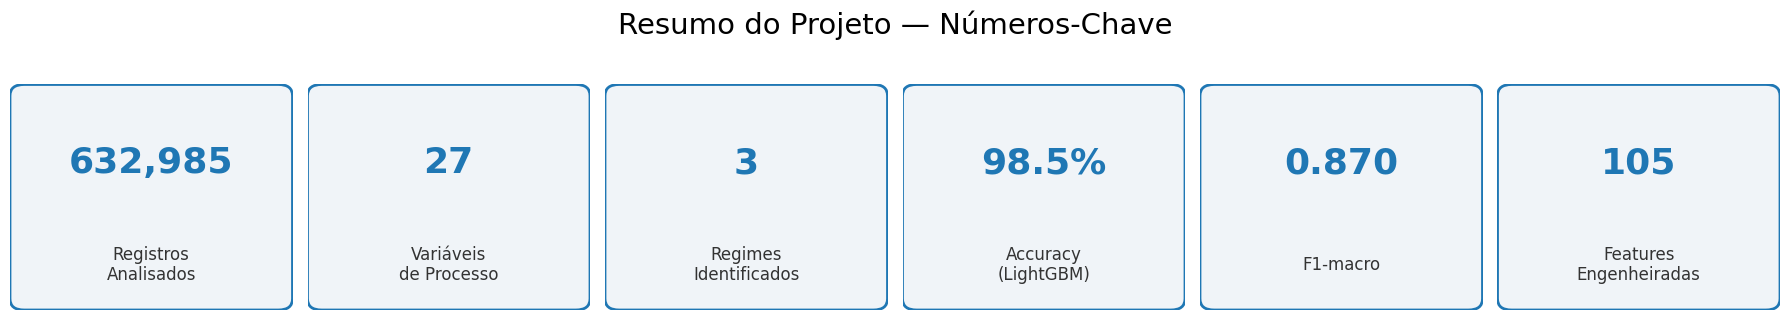

In [8]:
# Quadro resumo — gráfico com KPIs
from sklearn.metrics import accuracy_score, f1_score

acc_test = accuracy_score(df_pred['regime_real'], df_pred['regime_pred'])
f1_test = f1_score(df_pred['regime_real'], df_pred['regime_pred'], average='macro')

# Ler métricas de concordância
res_dict = dict(zip(df_resultados['aspecto'], df_resultados['valor']))

kpis = [
    ('Registros\nAnalisados', f'{len(df_rotulado):,}'),
    ('Variáveis\nde Processo', '27'),
    ('Regimes\nIdentificados', '3'),
    ('Accuracy\n(LightGBM)', f'{acc_test:.1%}'),
    ('F1-macro', f'{f1_test:.3f}'),
    ('Features\nEngenheiradas', '105'),
]

fig, axes = plt.subplots(1, len(kpis), figsize=(18, 3))

for ax, (titulo, valor) in zip(axes, kpis):
    ax.text(0.5, 0.65, valor, ha='center', va='center',
            fontsize=26, fontweight='bold', color='#1f77b4')
    ax.text(0.5, 0.2, titulo, ha='center', va='center',
            fontsize=12, color='#333333')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    # Borda
    rect = mpatches.FancyBboxPatch((0.05, 0.05), 0.9, 0.9,
                                    boxstyle="round,pad=0.05",
                                    facecolor='#f0f4f8', edgecolor='#1f77b4',
                                    linewidth=2)
    ax.add_patch(rect)

fig.suptitle('Resumo do Projeto — Números-Chave', fontsize=21, y=1.05)
plt.tight_layout()

fig.savefig(FIGURES_DIR / "S3b_06_quadro_resumo.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "quadro_resumo", fig, "S3b_06_quadro_resumo.png")
plt.show()

In [9]:
print(f"\n✓ {len(list(FIGURES_DIR.glob('S3b_*.png')))} figuras geradas para o pitch e relatório.")
print(f"  Diretório: {FIGURES_DIR}")


✓ 6 figuras geradas para o pitch e relatório.
  Diretório: C:\ScriptsDatamindsPIP\4-Projeto aplicado\figures\03_sprint3


In [10]:
# ==============================================================================
# Exportar notebook para HTML
# ==============================================================================
from pathlib import Path
from IPython.display import display, Javascript
import time

display(Javascript("IPython.notebook.save_checkpoint()"))
time.sleep(3)

from nbconvert import HTMLExporter
import nbformat

_nb_path = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\notebooks\03_sprint3\b_visualizacoes_finais.ipynb")
_html_dir = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\html")
_html_dir.mkdir(parents=True, exist_ok=True)

with open(_nb_path, encoding="utf-8") as _f:
    _nb_node = nbformat.read(_f, as_version=4)

_exporter = HTMLExporter()
_exporter.exclude_input = True
(_html_body, _) = _exporter.from_notebook_node(_nb_node)

_out_path = _html_dir / "b_visualizacoes_finais.html"
_out_path.write_text(_html_body, encoding="utf-8")
print("HTML exportado:", _out_path)

<IPython.core.display.Javascript object>

HTML exportado: C:\ScriptsDatamindsPIP\4-Projeto aplicado\html\b_visualizacoes_finais.html
